   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
/n Summary statistics
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


/tmp/ipykernel_1950/33927098.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


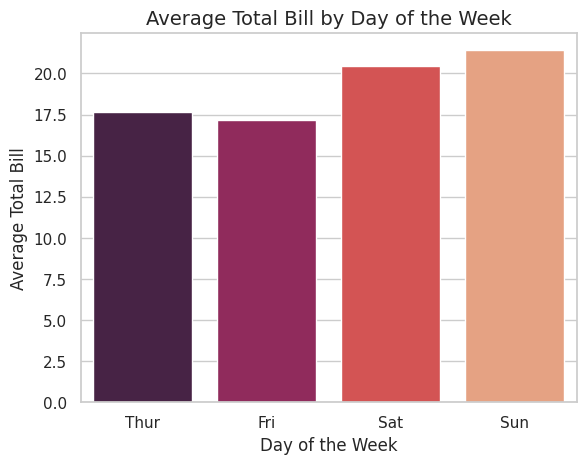

In [18]:
#task01
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("tips")

print("/n Summary statistics")
print(df.describe())

ax = sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    estimator="mean",
    errorbar=None,
    palette="rocket",


)

plt.title("Average Total Bill by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Average Total Bill", fontsize=12)



plt.show()

/tmp/ipykernel_1950/1047340487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


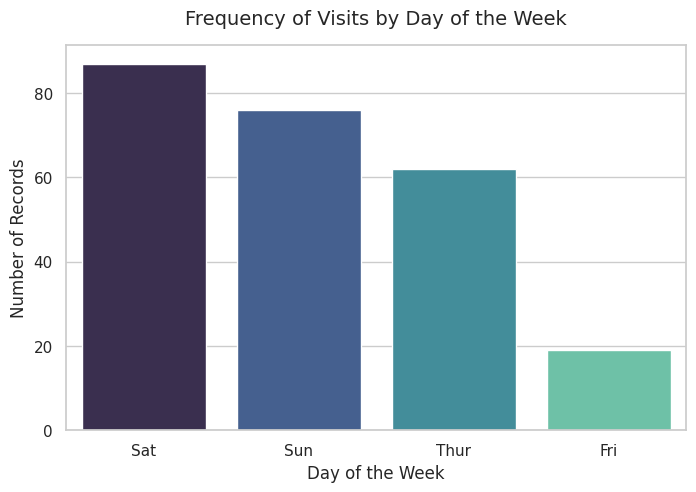

The most common category is sat


In [28]:
#Task02
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="day",
    order=df["day"].value_counts().index,
    palette="mako",
)

plt.title("Frequency of Visits by Day of the Week", fontsize=14, pad=15)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)


plt.show()
print("The most common category is sat")

/tmp/ipykernel_1950/1154050937.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df["total_bill"], palette="mako", kde=True)


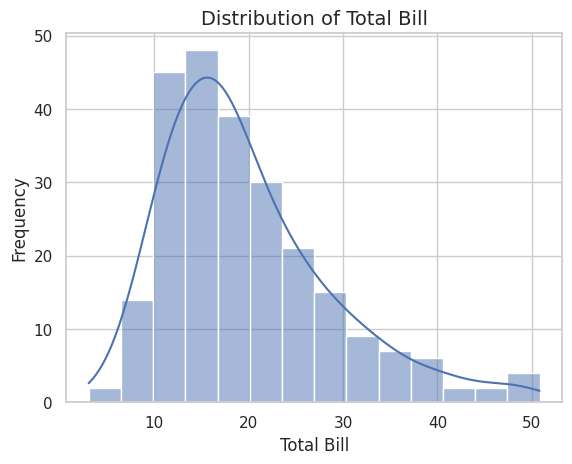


The distribution of 'total_bill' is skewed right (positively skewed).


In [31]:
# Task 3: Histogram: Distribution Shape
sns.histplot(df["total_bill"], kde=True)
plt.title("Distribution of Total Bill", fontsize=14)
plt.xlabel("Total Bill", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

print("\nThe distribution of 'total_bill' is skewed right (positively skewed).")


/tmp/ipykernel_1950/2646845259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sex", y="total_bill", data=df, palette="icefire")


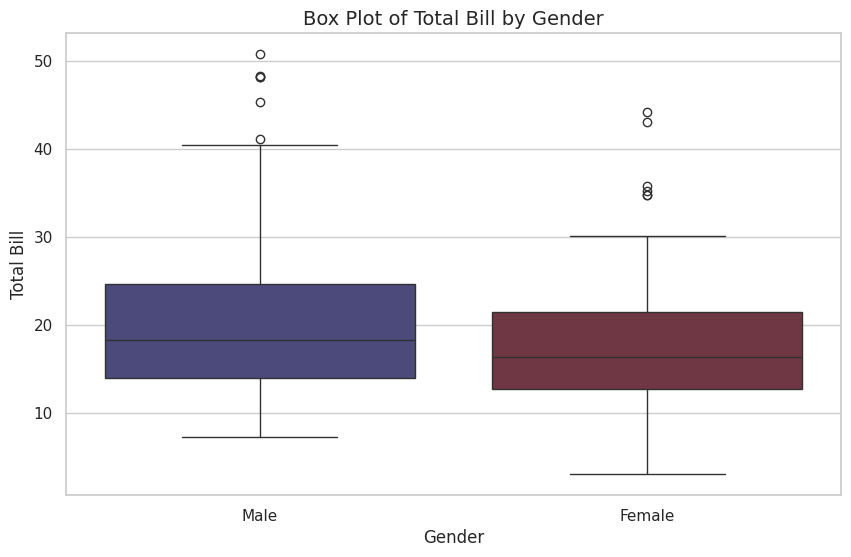


Based on the box plot, there appear to be approx 5 outliers for each gender, indicating some unusually high total bills.


In [38]:
# Task04
plt.figure(figsize=(10, 6))
sns.boxplot(x="sex", y="total_bill", data=df, palette="icefire")
plt.title("Box Plot of Total Bill by Gender", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Total Bill", fontsize=12)
plt.show()

print("\nBased on the box plot, there appear to be approx 5 outliers for each gender, indicating some unusually high total bills.")

In [35]:
# Task 5:
col = 'total_bill'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f"Q1 for '{col}': {Q1:.2f}")
print(f"Q3 for '{col}': {Q3:.2f}")
print(f"IQR for '{col}': {IQR:.2f}")
print(f"Lower bound for outliers: {lower_bound:.2f}")
print(f"Upper bound for outliers: {upper_bound:.2f}")

calculated_outliers_count = len(outliers)
print(f"\nNumber of outliers in '{col}' based on IQR calculation: {calculated_outliers_count}")

print(f"\n In Task 4, the box plot visually suggested several outliers, and the calculated count of {calculated_outliers_count} is consistent with that observation.")

Q1 for 'total_bill': 13.35
Q3 for 'total_bill': 24.13
IQR for 'total_bill': 10.78
Lower bound for outliers: -2.82
Upper bound for outliers: 40.30

Number of outliers in 'total_bill' based on IQR calculation: 9

Comparison to visual count from Task 4: In Task 4, the box plot visually suggested several outliers, and the calculated count of 9 is consistent with that observation.


In [42]:
# Task 6
from scipy import stats

col = 'total_bill'

df['zscore'] = stats.zscore(df[col])

outliers_z = df[df['zscore'].abs() > 3]

zscore_outliers_count = len(outliers_z)
print(f"Number of outliers in '{col}' based on Z-score method (Z > 3): {zscore_outliers_count}")

iqr_outliers_count = len(df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)])
print(f"Number of outliers in '{col}' based on IQR method: {iqr_outliers_count}")

print("\nComparison of IQR and Z-score outlier counts:")
if iqr_outliers_count == zscore_outliers_count:
    print("Both IQR and Z-score methods flagged the same number of outliers.")
else:
    print(f"The IQR method flagged {iqr_outliers_count} outliers, while the Z-score method flagged {zscore_outliers_count} outliers.")
    print("This difference can be attributed to the distribution shape of 'total_bill'.")
    print("As noted in Task 3, the distribution of 'total_bill' is skewed right (positively skewed).")
    print("The Z-score method assumes a normal distribution, and is more sensitive to outliers in skewed data than the IQR method,\n which is less affected by the distribution's shape.")

Number of outliers in 'total_bill' based on Z-score method (Z > 3): 4
Number of outliers in 'total_bill' based on IQR method: 9

Comparison of IQR and Z-score outlier counts:
The IQR method flagged 9 outliers, while the Z-score method flagged 4 outliers.
This difference can be attributed to the distribution shape of 'total_bill'.
As noted in Task 3, the distribution of 'total_bill' is skewed right (positively skewed).
The Z-score method assumes a normal distribution, and is more sensitive to outliers in skewed data than the IQR method,
 /n  which is less affected by the distribution's shape.


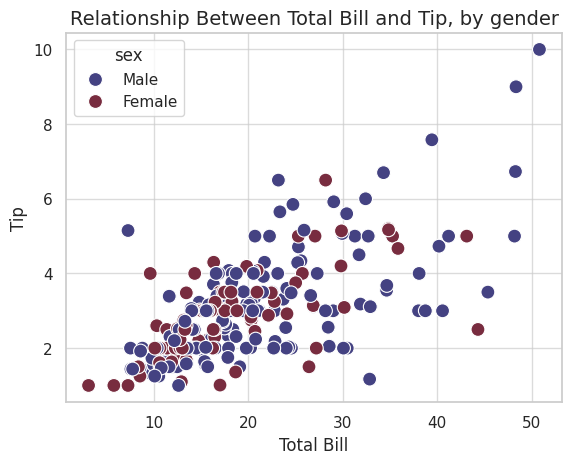

Correlation between 'total_bill' and 'tip': 0.68

There appears to be a strong positive relationship between 'total_bill' and 'tip', 
 meaning as the total bill increases, the tip tends to increase as well. The points colored by 'sex' show 
 that this positive trend generally holds for both males and females, though there is more spread at higher bill amount


In [50]:
# Task 7

sns.scatterplot(x='total_bill', y='tip', hue='sex', data=df, palette='icefire', s=100)
plt.title('Relationship Between Total Bill and Tip, by gender', fontsize=14)
plt.xlabel('Total Bill', fontsize=12)
plt.ylabel('Tip', fontsize=12)
plt.grid(True, alpha=0.7)
plt.show()

corelation = df['total_bill'].corr(df['tip'])
print(f"Correlation between 'total_bill' and 'tip': {corelation:.2f}")

print("\nThere appears to be a strong positive relationship between 'total_bill' and 'tip', \n meaning as the total bill increases, the tip tends to increase as well. The points colored by 'sex' show \n that this positive trend generally holds for both males and females, though there is more spread at higher bill amount")

/tmp/ipykernel_1950/3099239986.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill_by_day = df.groupby('day')['total_bill'].mean().reset_index()


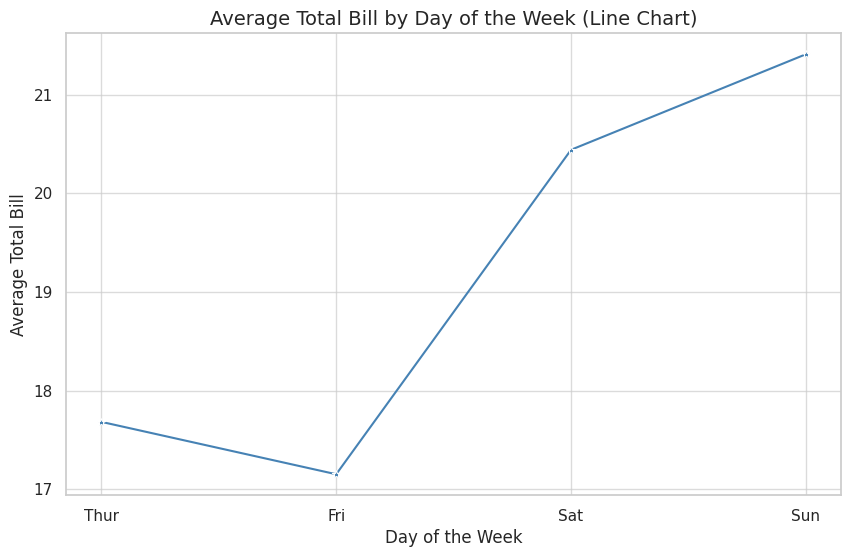

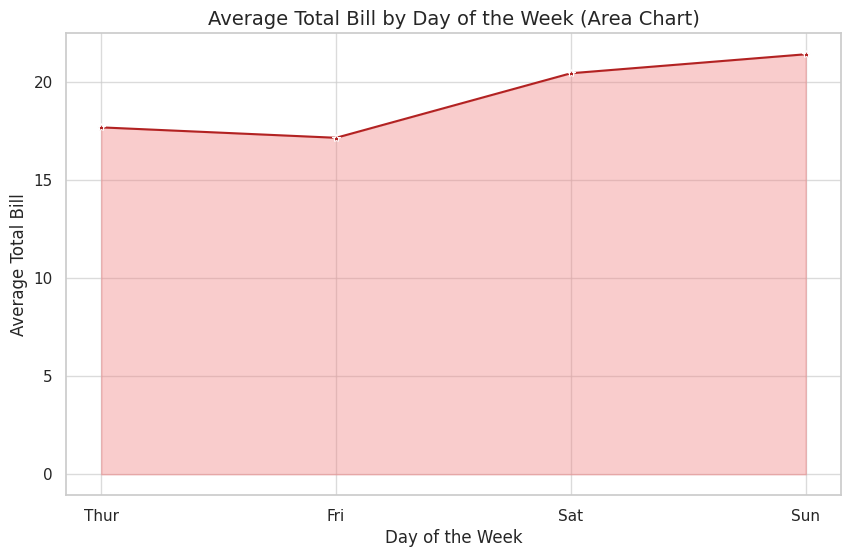


Comparison of Line Chart vs. Area Chart:
The line chart clearly shows the trend of the average total bill increasing from Thursday to Sunday.
It emphasizes the points and the path between them, focusing on the change from one point to the next.

The area chart, by filling the space below the line, gives a stronger visual impression of magnitude or cumulative value.
It makes the overall 'amount' more prominent and can make the differences between values feel more substantial,
especially in the peaks. While both convey the same trend, the area chart's fill can sometimes make smaller fluctuations
less noticeable if the overall area dominates, but in this case, it effectively highlights the increase
in average total bill towards the weekend and visually emphasizes the total 'volume' of average bills over the days.



In [55]:
# Task 8

import pandas as pd

day_order = ['Thur', 'Fri', 'Sat', 'Sun']
df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)

avg_bill_by_day = df.groupby('day')['total_bill'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='day', y='total_bill', data=avg_bill_by_day, marker='*', color='steelblue')
plt.title('Average Total Bill by Day of the Week (Line Chart)', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Total Bill', fontsize=12)
plt.grid(True, alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
plt.fill_between(avg_bill_by_day['day'], avg_bill_by_day['total_bill'], color='lightcoral', alpha=0.4)
sns.lineplot(x='day', y='total_bill', data=avg_bill_by_day, marker='*', color='firebrick')
plt.title('Average Total Bill by Day of the Week (Area Chart)', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Total Bill', fontsize=12)
plt.grid(True, alpha=0.7)
plt.show()

text = """
Comparison of Line Chart vs. Area Chart:
The line chart clearly shows the trend of the average total bill increasing from Thursday to Sunday.
It emphasizes the points and the path between them, focusing on the change from one point to the next.

The area chart, by filling the space below the line, gives a stronger visual impression of magnitude or cumulative value.
It makes the overall 'amount' more prominent and can make the differences between values feel more substantial,
especially in the peaks. While both convey the same trend, the area chart's fill can sometimes make smaller fluctuations
less noticeable if the overall area dominates, but in this case, it effectively highlights the increase
in average total bill towards the weekend and visually emphasizes the total 'volume' of average bills over the days.
"""
print(text)

/tmp/ipykernel_1950/3868306468.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_original = sns.countplot(


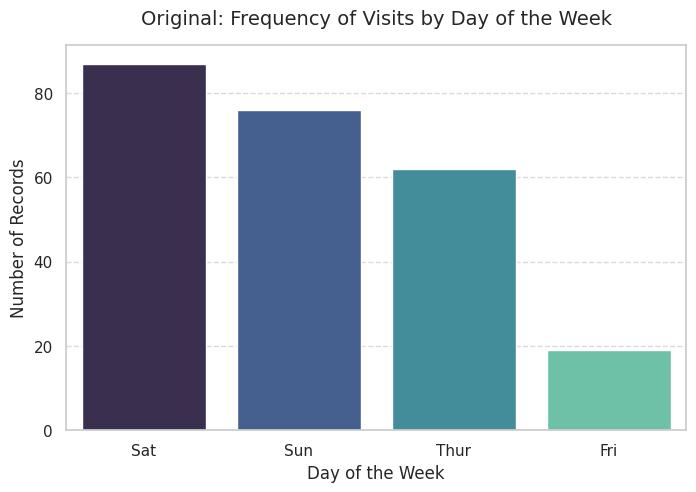

/tmp/ipykernel_1950/3868306468.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_truncated = sns.countplot(


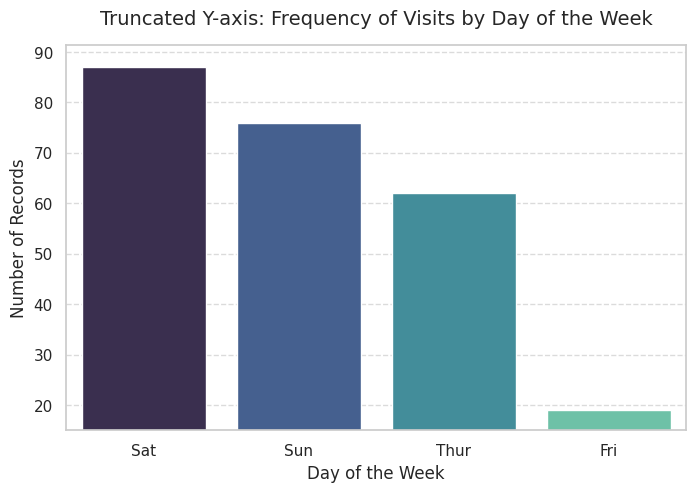


Comparison of Bar Charts with and without Truncated Y-axis:
The bar chart with the truncated y-axis (starting at 15) exaggerates the differences between the categories.
Even though the actual data values remain the same, the visual impression suggests a much larger relative disparity
in the number of visits between days, making the smaller bars appear disproportionately tiny compared to the taller ones.
This manipulation can mislead viewers by emphasizing differences that are not as significant as they appear.



In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(8, 5))
ax_original = sns.countplot(
    data=df,
    x="day",
    order=df["day"].value_counts().index,
    palette="mako",
)
plt.title("Original: Frequency of Visits by Day of the Week", fontsize=14, pad=15)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.show()

plt.figure(figsize=(8, 5))
ax_truncated = sns.countplot(
    data=df,
    x="day",
    order=df["day"].value_counts().index,
    palette="mako",
)
plt.title("Truncated Y-axis: Frequency of Visits by Day of the Week", fontsize=14, pad=15)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.ylim(bottom=15) # Deliberately truncate y-axis, choosing X above the minimum
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

text = """
Comparison of Bar Charts with and without Truncated Y-axis:
The bar chart with the truncated y-axis (starting at 15) exaggerates the differences between the categories.
Even though the actual data values remain the same, the visual impression suggests a much larger relative disparity
in the number of visits between days, making the smaller bars appear disproportionately tiny compared to the taller ones.
This manipulation can mislead viewers by emphasizing differences that are not as significant as they appear.
"""
print(text)
